In [1]:
import numpy as np 
import pandas as pd
import pickle
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path 
import re 
# get utils for thresholds
from src import util_analysis 
from src import util_process_prolific as util_process

from tqdm.auto import tqdm
import multiprocessing as mp
from scipy.stats import norm
from scipy.special import ndtri

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


## Load participant data and meta files 

In [2]:
### Load in experiment manifests with full transcripts
path_to_manifest = Path('/om/user/imgriff/datasets/human_word_rec_SWC_2024/full_cue_target_distractor_df_w_meta_transcripts.pdpkl')
df_w_transcripts = pd.read_pickle(path_to_manifest)

# unpack distractor words to individual columns

dist_1_word, dist_2_word = zip(*df_w_transcripts.distractor_word.apply(util_process.unpack_dist_words))

df_w_transcripts['distractor_1_word'] = dist_1_word
df_w_transcripts['distractor_2_word'] = dist_2_word
df_w_transcripts['targ_src_stem'] = df_w_transcripts.excerpt_src_fn.apply(util_process.slice_transcript_path)
df_w_transcripts['dist_1_src_stem'] = df_w_transcripts.excerpt_distractor_1_src_fn.apply(util_process.slice_transcript_path)
df_w_transcripts['dist_2_src_stem'] = df_w_transcripts.excerpt_distractor_2_src_fn.apply(util_process.slice_transcript_path)


In [18]:
def get_target_transcript(fname):
    return df_w_transcripts.loc[df_w_transcripts['targ_src_stem'].eq(fname), 'target_transcripts'].values[0]

def get_distractor_tscript(fname):
    if df_w_transcripts['dist_1_src_stem'].eq(fname).any():
        tscript = df_w_transcripts.loc[df_w_transcripts['dist_1_src_stem'].eq(fname), 'distractor_1_transcripts'].values[0]
    elif df_w_transcripts['dist_2_src_stem'].eq(fname).any():
        tscript = df_w_transcripts.loc[df_w_transcripts['dist_2_src_stem'].eq(fname), 'distractor_2_transcripts'].values[0]
    return tscript

def get_trial_task_type(target_loc):
    if isinstance(target_loc, list):
        if target_loc[1][0] == 0: # if target is at 0 azimuth 
            task = 'elevation direction'
        elif target_loc[1][0] != 0:
            task = 'azimuth direction'
    else:
        task = 'overlap'
    return task 
            

In [22]:
path_to_parts = Path('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/localization_check_data/localization_check')
part_results = sorted(list(path_to_parts.glob("*.csv")))

path_to_meta_data = Path('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/speaker_array_manifests/localization_check/')
meta_files = sorted(list(path_to_meta_data.glob("*meta.pkl")))

# meta_files
manifest_dict = {}
for meta_file in meta_files:
    if 'pilot' in meta_file.parent.stem:
        part_name = "pilot_" + "_".join(meta_file.stem.split('_')[:2])

    else:
        part_name = "_".join(meta_file.stem.split('_')[:2])
    manifest_dict[part_name] = meta_file


dfs = []
for result_file in part_results:
    try:
        part_name = result_file.stem
        # remove space 
        if 'pilot' in result_file.parent.stem:
            part_name = "pilot_" + "_".join(result_file.stem.split('_')[:2])
        if ' ' in part_name:
            part_name = part_name.split(' ')[0]
        # get digits in string pattern participant_xxx_ or participant_XXX. 
        part_ix = int(re.search(r'\d+', part_name).group())
        part_name_str = f"participant_{part_ix:03d}"
        manifest_file = manifest_dict[part_name_str]
        # part_df = pd.read_csv(result_file)
        # part_df = part_df
        part_df = util_process.get_part_df_loc_check(result_file)
        manifest_df = util_process.get_manifest_df(manifest_file)
        # merge on shared trial_index
        part_df = pd.merge(part_df[['trial_num', 'stimulus', 'response', 'correct_response', 'correct']],
                manifest_df, left_on='trial_num', right_on='trial_num', how='left')
        part_df['participant'] = part_name_str
        # part_df['task'] = part_df['target_loc'].apply(lambda x: 'direction' if isinstance(x, list) else 'overlap')
        part_df['task'] = part_df['target_loc'].apply(get_trial_task_type)

        dfs.append(part_df)
    except:
        continue

results_df = pd.concat(dfs, ignore_index=True)
results_df.loc[results_df.task == 'elevation direction', "direction_label"] = results_df.loc[results_df.task == 'elevation direction', ['target_elev', 'distractor_elev']].apply(lambda x: int((x[0] < x[1])), axis=1) # map: above = 0 below = 1 
results_df.loc[results_df.task == 'overlap', "overlap_label"] = results_df.loc[results_df.task == 'overlap', ['target_elev', 'distractor_elev']].apply(lambda x: int(x[0] != x[1]), axis=1)  # co-located = 0, separated = 1 


In [26]:
results_df.loc[results_df.task == 'elevation direction'].groupby('elev_delta').direction_label.value_counts()

elev_delta  direction_label
10          0.0                67
            1.0                53
60          0.0                62
            1.0                58
Name: direction_label, dtype: int64

In [27]:
results_df

,trial_num,stimulus,response,correct_response,correct,target_loc,distractor_loc,azim_delta,elev_delta,snr,...,n_distractors,distractor_1_word,distractor_2_word,src_fn,distractor_1_fn,distractor_2_fn,participant,task,direction_label,overlap_label
0,135,['<p>Did the cued voice play from above or bel...,0,1.0,0.0,"[(0, 0), (0, -10)]","[(0, -20), (0, -20)]",0,10,0,...,2,first,under,full_df_ix_1552_could-s-whistler,full_df_ix_1552_under-popularoutcast_eg_1,full_df_ix_1552_first-lily5lace_eg_0,participant_001,elevation direction,0.0,NaN
1,136,['<p>Did the cued voice play from above or bel...,1,1.0,1.0,"[(0, 0), (0, -20)]","[(0, 40), (0, 40)]",0,60,0,...,2,local,service,full_df_ix_0921_tower-the-voice-of-hassocks,full_df_ix_0921_local-slovakjoe_eg_0,full_df_ix_0921_service-matthewdgonzalez_eg_1,participant_001,elevation direction,1.0,NaN
2,137,['<p>Did the cued voice play from above or bel...,1,1.0,1.0,"[(0, 0), (0, -10)]","[(0, -20), (0, -20)]",0,10,0,...,2,other,island,full_df_ix_0497_again-karltalk,full_df_ix_0497_island-mckaysalisbury_eg_1,full_df_ix_0497_other-sethda_eg_0,participant_001,elevation direction,0.0,NaN
3,138,['<p>Did the cued voice play from above or bel...,0,1.0,0.0,"[(0, 0), (0, 40)]","[(0, -20), (0, -20)]",0,60,0,...,2,which,whether,full_df_ix_1134_french-popularoutcast,full_df_ix_1134_which-demi_eg_0,full_df_ix_1134_whether-ljl_eg_1,participant_001,elevation direction,0.0,NaN
4,139,['<p>Did the cued voice play from above or bel...,1,1.0,1.0,"[(0, 0), (0, 40)]","[(0, 30), (0, 30)]",0,10,0,...,2,spanish,first,full_df_ix_1334_second-k9taylor,full_df_ix_1334_first-tonyle_eg_1,full_df_ix_1334_spanish-mangst_eg_0,participant_001,elevation direction,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
762,4,['<p>Did the voices play from the same or diff...,1,1.0,1.0,"(0, -20)","[(-60, -20), (60, -20)]",60,0,0,...,2,example,island,full_df_ix_1619_found-dcoetzee,full_df_ix_1619_example-popularoutcast_eg_0,full_df_ix_1619_island-persian-poet-gal_eg_1,participant_004,overlap,NaN,0.0
763,5,['<p>Did the voices play from the same or diff...,0,0.0,1.0,"(0, 40)","[(-10, 40), (10, 40)]",10,0,0,...,2,across,remains,full_df_ix_0997_ancient-persian-poet-gal,full_df_ix_0997_across-mckaysalisbury_eg_0,full_df_ix_0997_remains-s-whistler_eg_1,participant_004,overlap,NaN,0.0
764,6,['<p>Did the voices play from the same or diff...,1,0.0,0.0,"(0, 40)","[(-60, 40), (60, 40)]",60,0,0,...,2,access,class,full_df_ix_0410_support-lily5lace,full_df_ix_0410_access-persian-poet-gal_eg_0,full_df_ix_0410_class-flyingtoaster_eg_1,participant_004,overlap,NaN,0.0
765,7,['<p>Did the voices play from the same or diff...,1,0.0,0.0,"(0, -20)","[(-10, -20), (10, -20)]",10,0,0,...,2,however,again,full_df_ix_0805_private-cognate247,full_df_ix_0805_however-s-whistler_eg_0,full_df_ix_0805_again-runfellow_eg_1,participant_004,overlap,NaN,0.0


## Co-location analysis

In [28]:
coloc_results = results_df[results_df.task == 'overlap'].copy()
coloc_results['correct'] = coloc_results['overlap_label'] == coloc_results['response']
# coloc_summary = coloc_results.groupby(['participant',  'elev_delta']).correct.mean().reset_index()
# coloc_summary

## measure d prime at 10 and 60 degree deltas for each participant
d_prime = []
for (part, data) in coloc_results.groupby(['participant']):
    # get false alarm rate 
    fa = 1 - data[data.elev_delta == 0].correct.mean()
    hit_10 = np.clip(data[data.elev_delta == 10].correct.mean(), a_min=0.01, a_max=0.99)
    d_prime_10 = ndtri(hit_10) - ndtri(fa)
    d_prime.append({'participant': part, 'd_prime': d_prime_10, 'elev_delta': 10})

    hit_60 = np.clip(data[data.elev_delta == 60].correct.mean(), a_min=0.01, a_max=0.99)
    d_prime_60 = ndtri(hit_60) - ndtri(fa)
    d_prime.append({'participant': part, 'd_prime': d_prime_60, 'elev_delta': 60})
d_prime_df = pd.DataFrame(d_prime)

N = d_prime_df.participant.nunique()

In [29]:
d_prime_df

,participant,d_prime,elev_delta
0,participant_001,0.381346,10
1,participant_001,2.278603,60
2,participant_002,0.438673,10
3,participant_002,2.996397,60
4,participant_003,0.000000,10
5,participant_003,2.579695,60
6,participant_004,-1.255976,10
7,participant_004,0.740556,60


Text(0.5, 1.1, 'Detecting talker separation in elevation (N=4)')

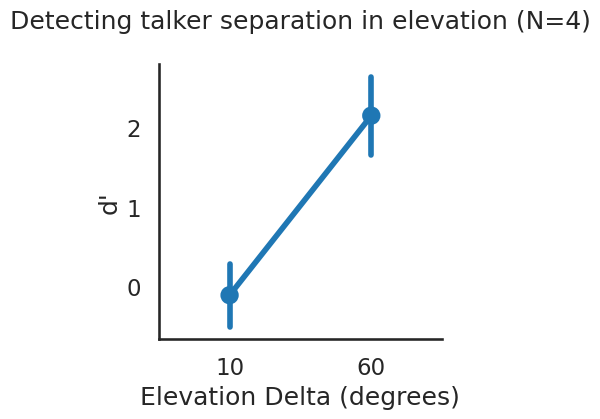

In [30]:
# d_prime_df = pd.DataFrame(d_prime)
# plot 
sns.set_context('talk')
sns.set_style('white')
g = sns.catplot(data=d_prime_df, kind='point', x='elev_delta', y='d_prime', aspect=1, height=4, errorbar='se')
g.set_axis_labels('Elevation Delta (degrees)', 'd\'')
# g.set(ylim=(0, 3))
plt.title(f'Detecting talker separation in elevation (N={N})', y=1.1)



### Direction difference 

In [36]:
# ##### Look at percent correct 
# direction_trials = results_df[results_df.task == 'direction'].copy()
# # direction_trials['cue_azim'], direction_trials['cue_elev'] = zip(*direction_trials['target_loc'].apply(lambda x: x[0]))
# direction_trials['elev_delta_rel'] =  direction_trials['distractor_elev'] - direction_trials['target_elev']
# direction_summary = direction_trials.groupby(['participant',  'cue_elev', 'elev_delta_rel',  'target_elev', 'elev_delta']).correct.mean().reset_index()
direction_trials = results_df[results_df.task != 'overlap'].copy()
direction_trials.loc[direction_trials.task == 'elevation direction', "delta"] = direction_trials.loc[direction_trials.task == 'elevation direction', 'elev_delta']
direction_summary = direction_trials.groupby(['participant',  'delta', 'task']).correct.mean().reset_index()
print(direction_summary)

       participant  delta                 task  correct
0  participant_001     10  elevation direction    0.475
1  participant_001     60  elevation direction    0.350
2  participant_002     10  elevation direction    0.500
3  participant_002     60  elevation direction    0.375
4  participant_003     10  elevation direction    0.500
5  participant_003     60  elevation direction    0.600


Text(0.5, 1.1, 'Report elevation direction (N=4)')

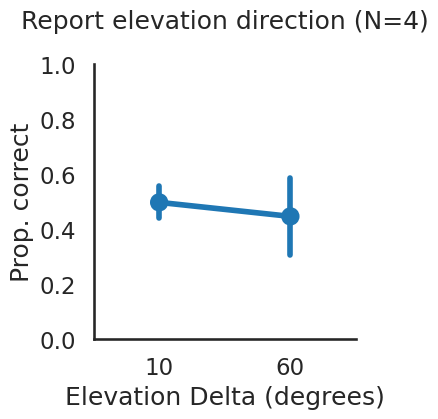

In [32]:
# Plot summary 
sns.set_context('talk')
sns.set_style('white')
g = sns.catplot(data=direction_summary, kind='point', x='elev_delta', y='correct',   aspect=1, height=4, errorbar='se')
g.set_axis_labels('Elevation Delta (degrees)', 'Prop. correct')
g.set(ylim=(0, 1))
plt.title(f'Report elevation direction (N={N})', y=1.1)


In [31]:
direction_summary

,participant,cue_elev,elev_delta_rel,target_elev,elev_delta,correct
0,participant_001,0,-60,40,60,0.043478
1,participant_001,0,-10,-10,10,0.400000
2,participant_001,0,-10,40,10,0.500000
3,participant_001,0,10,-20,10,0.700000
4,participant_001,0,10,30,10,0.250000
5,participant_001,0,60,-20,60,0.764706
6,participant_002,0,-60,40,60,0.217391
7,participant_002,0,-10,-10,10,0.400000
8,participant_002,0,-10,40,10,0.333333
9,participant_002,0,10,-20,10,0.800000


In [ ]:
direction_summary

,participant,cue_elev,elev_delta_rel,target_elev,elev_delta,correct
0,participant_001,0,-60,40,60,0.043478
1,participant_001,0,-10,-10,10,0.400000
2,participant_001,0,-10,40,10,0.500000
3,participant_001,0,10,-20,10,0.700000
4,participant_001,0,10,30,10,0.250000
5,participant_001,0,60,-20,60,0.764706
6,participant_002,0,-60,40,60,0.217391
7,participant_002,0,-10,-10,10,0.400000
8,participant_002,0,-10,40,10,0.333333
9,participant_002,0,10,-20,10,0.800000


In [33]:
direction_summary[direction_summary['elev_delta'] == 60].correct.mean()

0.4460517902813299

In [24]:
# # Plot summary 
# sns.set_context('talk')
# sns.set_style('white')
# direction_summary['loc_re_cue'] = (direction_summary['target_elev'] > direction_summary['cue_elev']).astype('int')

# direction_summary['loc_re_cue'] = direction_summary['loc_re_cue'].replace({0: 'Target below cue', 1: 'Target above cue'})
# g = sns.catplot(data=direction_summary, kind='point', x='elev_delta_rel', y='correct', col='loc_re_cue', aspect=1, height=4, errorbar='se')
# g.set_axis_labels('Elevation Delta (degrees)', 'Percent Correct')
# g.set_titles('{col_name}')
# g.set(ylim=(0, 1))


In [23]:
direction_summary.loc_re_cue.value_counts()

Target above cue    9
Target below cue    9
Name: loc_re_cue, dtype: int64